# Mineração de Dados — Projeto Final
## Análise de Problemas de SQL da Plataforma Beecrowd sob a Perspectiva Pedagógica

**Programa:** PPGCO — Faculdade de Computação / UFU · **Disciplina:** Mineração de Dados
**Estudante:** Ramayane Bonacin Braga
**Professor:** Leandro Nogueira Couto

Este notebook aplica o fluxo completo de mineração de dados a um dataset de **51 problemas de SQL**
da plataforma Beecrowd (ex-URI Online Judge), anotados com **21 conceitos de SQL** e variáveis de
enunciado e de estrutura.

### Questões de pesquisa
- **QP1** — A plataforma Beecrowd, no recorte analisado, é um instrumento adequado para o ensino de SQL?
- **QP2** — O nível de dificuldade declarado é coerente com a complexidade técnica real dos problemas?
- **QP3** — O contexto narrativo dos enunciados se relaciona com os conceitos exigidos na solução?
- **QP4** — Os problemas cobrem suficientemente os conceitos de SQL (básico → avançado) para as necessidades curriculares?

### Técnicas de Aprendizado de Máquina aplicadas
1. **Clusterização (K-Means)** — descoberta não supervisionada de grupos de problemas por perfil conceitual/estrutural.
2. **Regras de associação (Apriori)** — combinações de conceitos que coexistem no mesmo SELECT (sequências de ensino).


In [58]:
# Dependência extra
!pip -q install mlxtend

import os, warnings
warnings.filterwarnings("ignore")

CSV = "dataset_beecrowd_refinado.csv"

if os.path.exists(CSV):
    print("Dataset disponível: True")
else:
    print("Dataset disponível: False")
    print()
    print(f"O arquivo '{CSV}' ainda não está no ambiente.")
    print("Carregue-o pelo painel de Arquivos (ícone de pasta 📁 na barra esquerda ->")
    print("botão de upload ⬆) e execute esta célula novamente.")

Dataset disponível: True


## 1. Configuração e carga dos dados

`pandas`/`numpy` para manipulação, `matplotlib`/`seaborn` para visualização, `scikit-learn` para
o aprendizado de máquina (K-Means, padronização, PCA), `mlxtend` para regras de associação e
`scipy.stats` para os testes de correlação. A reprodutibilidade é garantida por `random_state=42`.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
from mlxtend.frequent_patterns import apriori, association_rules

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

df = pd.read_csv("dataset_beecrowd_refinado.csv")
print("Dimensões:", df.shape)
df.head(3)

Dimensões: (51, 42)


,problema_id,titulo,autor,url,enunciado,nivel,num_resolvidos,num_fks_entrada,entrada_tem_ddl_avancado,enunciado_num_sentencas,enunciado_riqueza_lexica,num_conceitos_total,faixa_conceitual,conceito_primario,conceitos_lista,usa_where,usa_order_by,usa_distinct,usa_like,usa_in,usa_between,usa_agregacao,usa_join,usa_group_by,usa_having,usa_subconsulta,usa_subconsulta_correlacionada,usa_union,usa_case,usa_funcao_data,usa_tratamento_null,usa_cast,usa_recursao,usa_funcao_janela,usa_pivot,usa_funcao_string,sql_entrada,sql_saida,complexidade_tecnica,discrepancia_nivel_complexidade,cluster_k2,cluster_k3
0,2602,Select Básico,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2602,Sua empresa está fazendo um levantamento de qu...,4,41417,0,0,2,0.846,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,SELECT name from customers where state= 'RS';,1.5,1.169,0,0
1,2603,Endereço dos Clientes,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2603,A empresa fará um evento comemorando os 20 ano...,1,36554,0,0,3,0.793,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT name,street from customers where city =...",1.5,-0.289,0,0
2,2604,Menores que 10 ou Maiores que 100,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2604,O setor financeiro da empresa precisa de um re...,2,32834,0,0,1,0.857,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT id,name FROM products where price < 10 ...",1.5,0.197,0,0


In [60]:
# Colunas de conceito (21 flags problema × conceito) e rótulos SQL canônicos
usa_cols = [c for c in df.columns if c.startswith("usa_")]
print(f"{len(usa_cols)} conceitos anotados")

ROTULO = {
    "usa_where": "WHERE", "usa_order_by": "ORDER BY", "usa_distinct": "DISTINCT",
    "usa_like": "LIKE", "usa_in": "IN", "usa_between": "BETWEEN",
    "usa_agregacao": "Agregação", "usa_join": "JOIN", "usa_group_by": "GROUP BY",
    "usa_having": "HAVING", "usa_subconsulta": "Subconsulta",
    "usa_subconsulta_correlacionada": "Subcons. correl.", "usa_union": "UNION",
    "usa_case": "CASE", "usa_funcao_data": "Função de data",
    "usa_tratamento_null": "Tratamento de NULL", "usa_cast": "CAST",
    "usa_recursao": "Recursão", "usa_funcao_janela": "Função de janela",
    "usa_pivot": "PIVOT", "usa_funcao_string": "Função de string",
}
def rotular(cols):
    return [ROTULO.get(c, c) for c in cols]

21 conceitos anotados


## 2. Pré-processamento e verificação de qualidade



In [61]:
# Tipos e ausentes
info = pd.DataFrame({"dtype": df.dtypes.astype(str), "n_nulos": df.isna().sum()})
print("Colunas com valores ausentes:")
print(info[info.n_nulos > 0] if info.n_nulos.sum() else "  (nenhuma)")

# Integridade: num_conceitos_total == soma das flags; ausência de órfãos
soma_flags = df[usa_cols].sum(axis=1)
inconsistentes = int((df["num_conceitos_total"] != soma_flags).sum())
orfaos = int((soma_flags == 0).sum())
print(f"\nLinhas inconsistentes (total != soma flags): {inconsistentes}")
print(f"Problemas sem nenhum conceito (órfãos): {orfaos}")
assert inconsistentes == 0 and orfaos == 0, "Falha de integridade no dataset!"
print("Integridade OK.")

Colunas com valores ausentes:
  (nenhuma)

Linhas inconsistentes (total != soma flags): 0
Problemas sem nenhum conceito (órfãos): 0
Integridade OK.


In [62]:
# Estatística descritiva das principais variáveis numéricas
num_cols = ["nivel", "num_resolvidos", "num_conceitos_total", "num_fks_entrada",
            "enunciado_num_sentencas", "enunciado_riqueza_lexica",
            "complexidade_tecnica", "discrepancia_nivel_complexidade"]
df[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
nivel,51.0,3.647,2.057,1.000,2.000,3.000,5.000,9.000
num_resolvidos,51.0,10540.529,9846.373,50.000,2655.500,7175.000,14521.500,41417.000
num_conceitos_total,51.0,3.353,2.448,1.000,2.000,3.000,4.000,10.000
num_fks_entrada,51.0,0.980,1.726,0.000,0.000,0.000,1.000,10.000
enunciado_num_sentencas,51.0,3.137,1.549,1.000,2.000,3.000,4.000,8.000
enunciado_riqueza_lexica,51.0,0.752,0.099,0.532,0.695,0.754,0.805,0.955
complexidade_tecnica,51.0,5.578,4.087,1.500,2.500,4.500,6.750,15.000
discrepancia_nivel_complexidade,51.0,-0.000,0.988,-2.980,-0.533,-0.051,0.683,1.897


## 3. Análise exploratória (EDA)




### 3.1 Distribuições univariadas




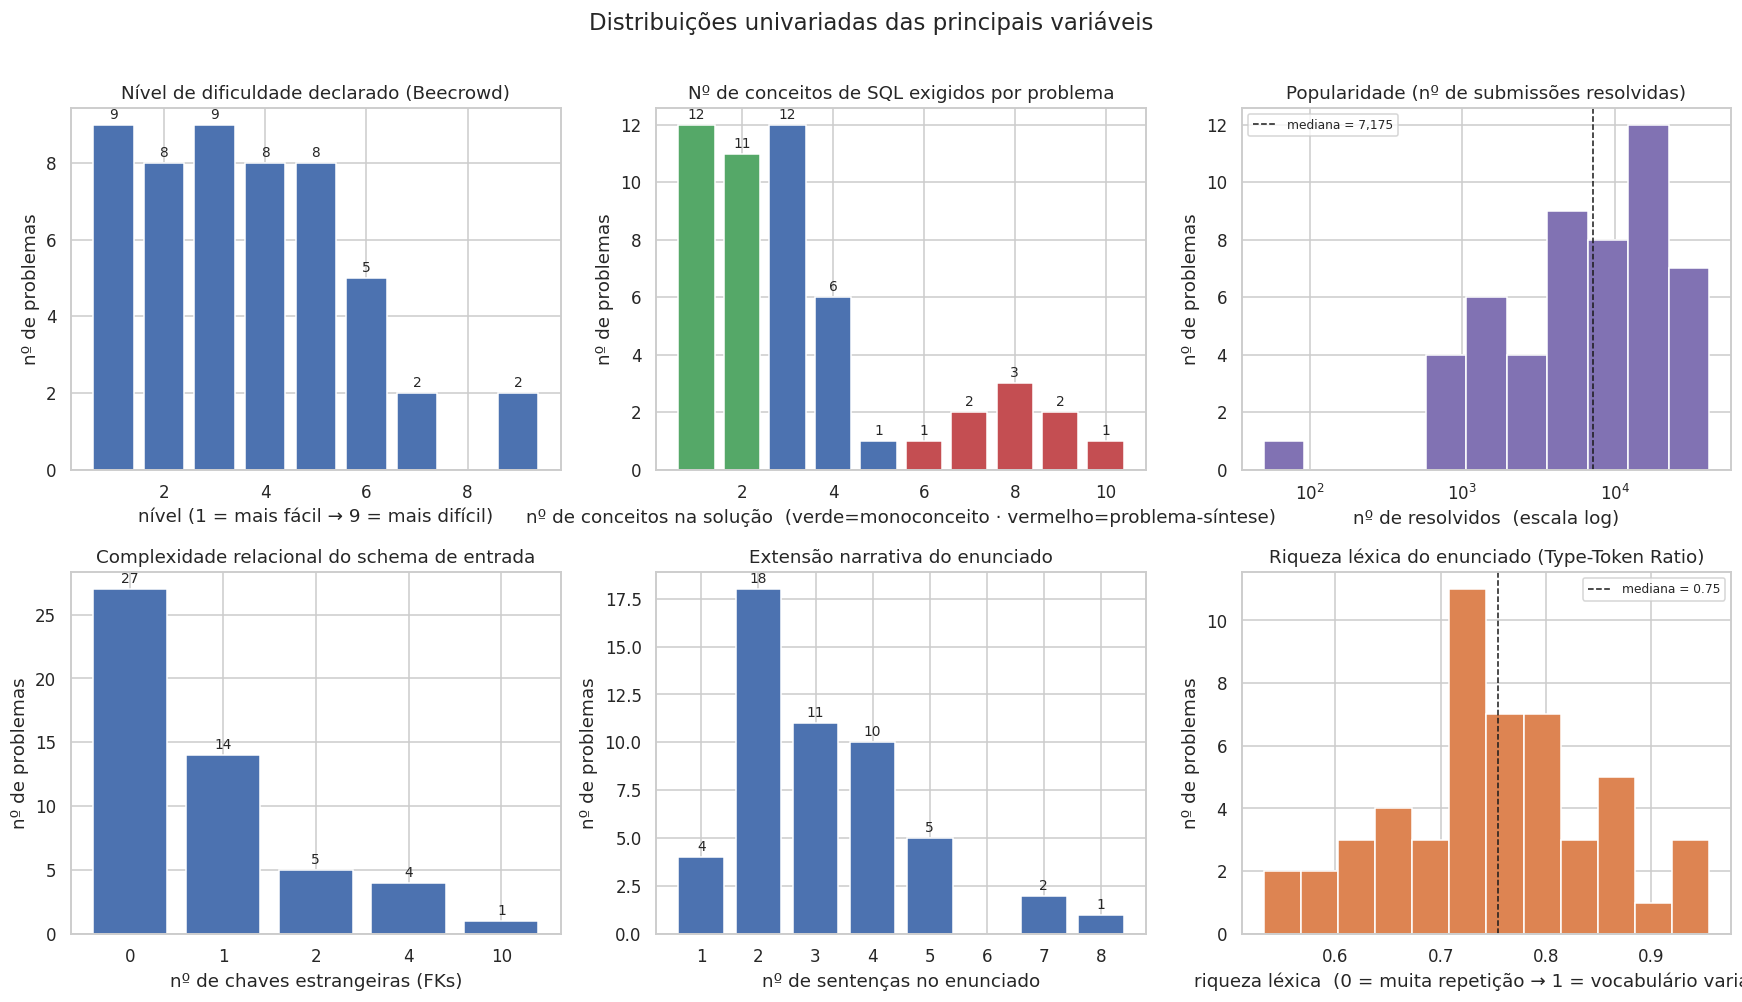

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- (a) nível declarado: contagem por valor -------------------------------
ax = axes[0, 0]
vc = df["nivel"].value_counts().sort_index()
b = ax.bar(vc.index, vc.values, color="#4C72B0", edgecolor="white")
ax.bar_label(b, padding=2, fontsize=9)
ax.set_title("Nível de dificuldade declarado (Beecrowd)")
ax.set_xlabel("nível (1 = mais fácil → 9 = mais difícil)")
ax.set_ylabel("nº de problemas")

# --- (b) nº de conceitos por problema: contagem por valor -------------------
ax = axes[0, 1]
vc = df["num_conceitos_total"].value_counts().sort_index()
cores = ["#55A868" if v <= 2 else "#C44E52" if v >= 6 else "#4C72B0" for v in vc.index]
b = ax.bar(vc.index, vc.values, color=cores, edgecolor="white")
ax.bar_label(b, padding=2, fontsize=9)
ax.set_title("Nº de conceitos de SQL exigidos por problema")
ax.set_xlabel("nº de conceitos na solução  (verde=monoconceito · vermelho=problema-síntese)")
ax.set_ylabel("nº de problemas")

# --- (c) popularidade: histograma em escala log ----------------------------
ax = axes[0, 2]
ax.hist(df["num_resolvidos"], bins=np.logspace(np.log10(df["num_resolvidos"].min()),
        np.log10(df["num_resolvidos"].max()), 12), color="#8172B3", edgecolor="white")
ax.set_xscale("log")
ax.axvline(df["num_resolvidos"].median(), color="k", ls="--", lw=1,
           label=f'mediana = {int(df["num_resolvidos"].median()):,}')
ax.set_title("Popularidade (nº de submissões resolvidas)")
ax.set_xlabel("nº de resolvidos  (escala log)")
ax.set_ylabel("nº de problemas"); ax.legend(fontsize=8)

# --- (d) nº de chaves estrangeiras no schema: contagem por valor ------------
ax = axes[1, 0]
vc = df["num_fks_entrada"].value_counts().sort_index()
b = ax.bar(vc.index.astype(str), vc.values, color="#4C72B0", edgecolor="white")
ax.bar_label(b, padding=2, fontsize=9)
ax.set_title("Complexidade relacional do schema de entrada")
ax.set_xlabel("nº de chaves estrangeiras (FKs)")
ax.set_ylabel("nº de problemas")

# --- (e) nº de sentenças do enunciado: contagem por valor -------------------
ax = axes[1, 1]
vc = df["enunciado_num_sentencas"].value_counts().sort_index()
b = ax.bar(vc.index, vc.values, color="#4C72B0", edgecolor="white")
ax.bar_label(b, padding=2, fontsize=9)
ax.set_title("Extensão narrativa do enunciado")
ax.set_xlabel("nº de sentenças no enunciado")
ax.set_ylabel("nº de problemas")

# --- (f) riqueza léxica: histograma contínuo com mediana -------------------
ax = axes[1, 2]
ax.hist(df["enunciado_riqueza_lexica"], bins=12, color="#DD8452", edgecolor="white")
ax.axvline(df["enunciado_riqueza_lexica"].median(), color="k", ls="--", lw=1,
           label=f'mediana = {df["enunciado_riqueza_lexica"].median():.2f}')
ax.set_title("Riqueza léxica do enunciado (Type-Token Ratio)")
ax.set_xlabel("riqueza léxica  (0 = muita repetição → 1 = vocabulário variado)")
ax.set_ylabel("nº de problemas"); ax.legend(fontsize=8)

fig.suptitle("Distribuições univariadas das principais variáveis", fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

### 3.2 Cobertura conceitual



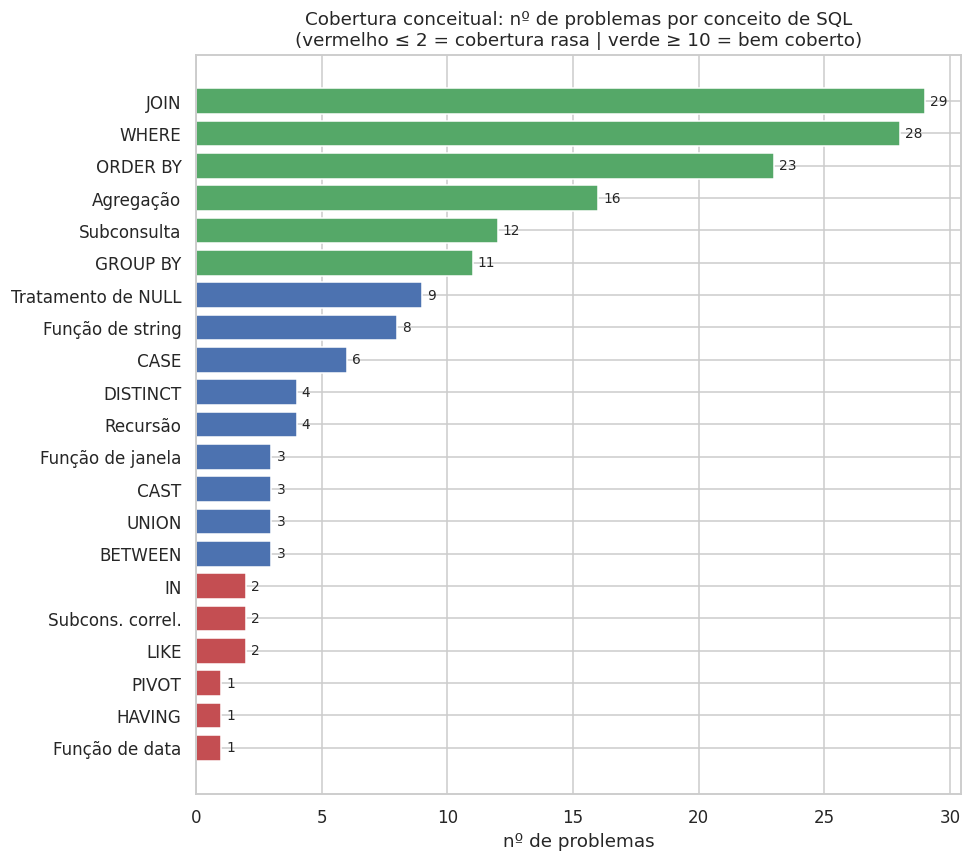

In [64]:
freq = df[usa_cols].sum().sort_values(ascending=True)
freq.index = rotular(freq.index)

plt.figure(figsize=(9, 8))
cores = ["#C44E52" if v <= 2 else "#55A868" if v >= 10 else "#4C72B0" for v in freq.values]
plt.barh(freq.index, freq.values, color=cores)
for i, v in enumerate(freq.values):
    plt.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)
plt.title("Cobertura conceitual: nº de problemas por conceito de SQL\n"
          "(vermelho ≤ 2 = cobertura rasa | verde ≥ 10 = bem coberto)")
plt.xlabel("nº de problemas"); plt.tight_layout(); plt.show()

### 3.3 Conceitos por faixa conceitual e por nível declarado (boxplots)

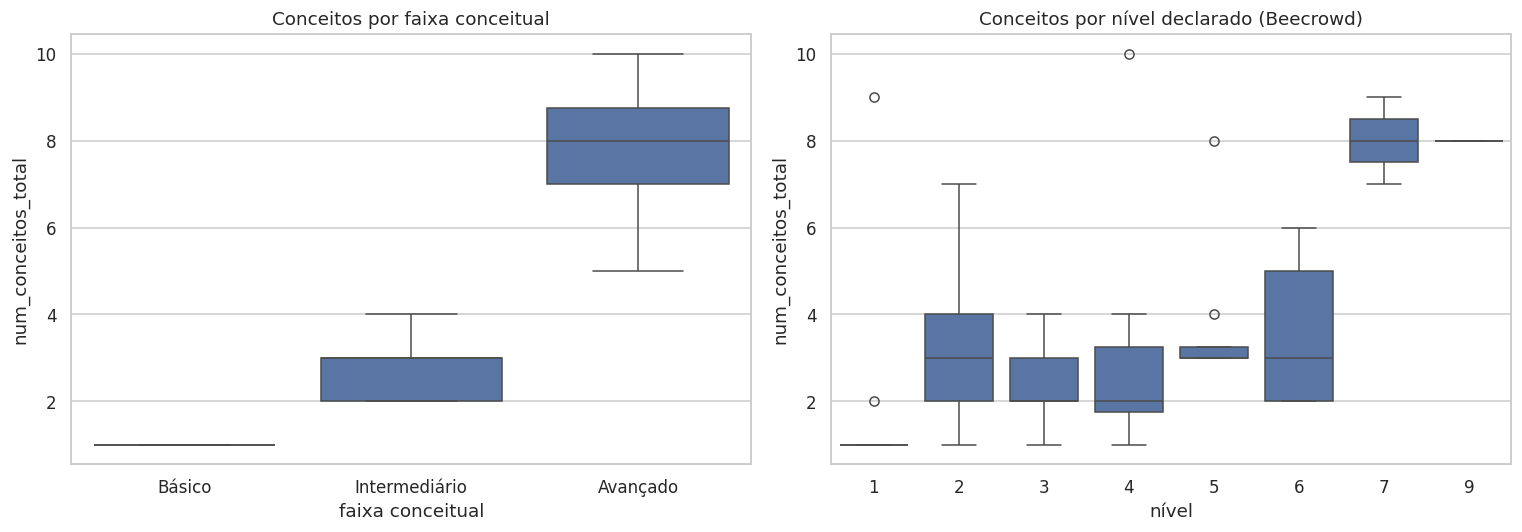

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ordem = ["Básico", "Intermediário", "Avançado"]
dfp = df.copy()
dfp["faixa_conceitual"] = pd.Categorical(dfp["faixa_conceitual"], categories=ordem, ordered=True)
dfp = dfp.sort_values("faixa_conceitual")
sns.boxplot(data=dfp, x="faixa_conceitual", y="num_conceitos_total", ax=axes[0])
axes[0].set_title("Conceitos por faixa conceitual"); axes[0].set_xlabel("faixa conceitual")
sns.boxplot(data=dfp, x="nivel", y="num_conceitos_total", ax=axes[1])
axes[1].set_title("Conceitos por nível declarado (Beecrowd)"); axes[1].set_xlabel("nível")
plt.tight_layout(); plt.show()

### 3.4 Validação da classificação em faixas (Básico / Intermediário / Avançado)

Coerência faixa × conceitos complexos:
  Problemas 'Básico' que usam conceito avançado : 0  (esperado 0)
  Problemas 'Avançado' sem nenhum conceito complexo: 0  (esperado 0)
  Média de conceitos avançados por faixa:
faixa_conceitual
Básico           0.00
Intermediário    0.07
Avançado         2.00


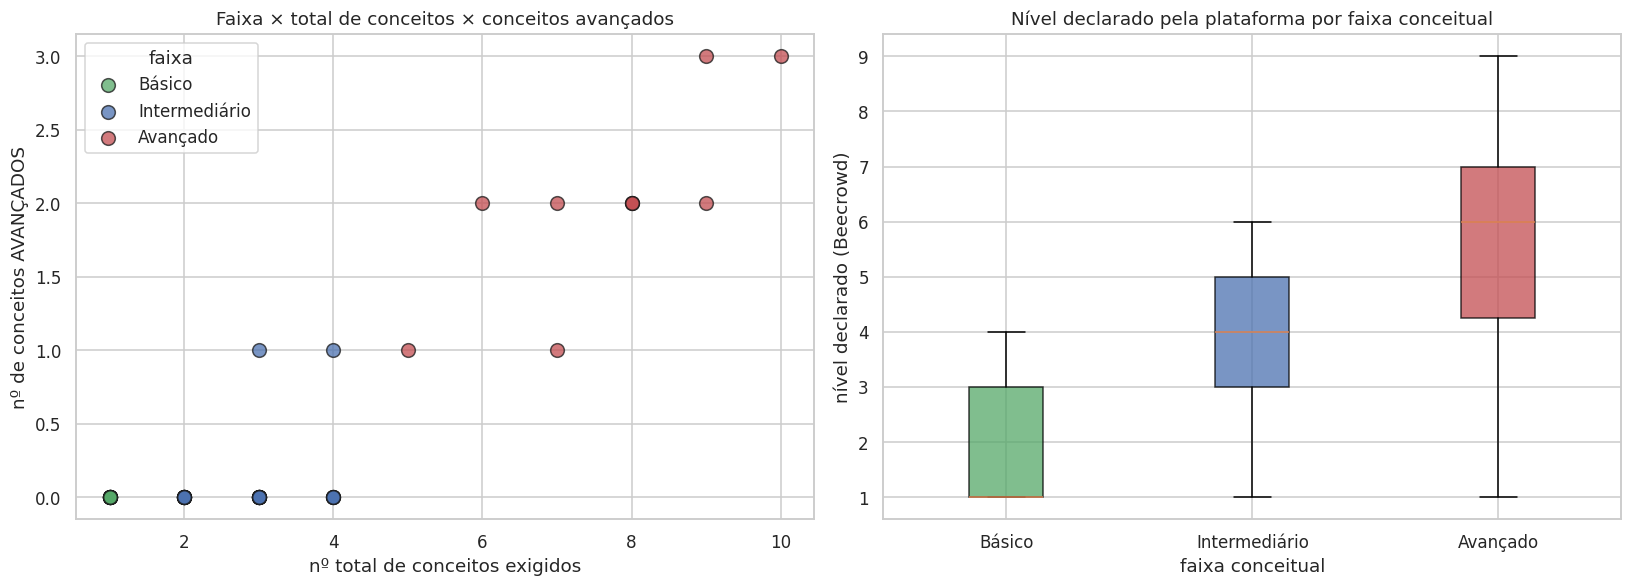


Casos de tensão entre faixa (conceitual) e nível declarado:
  'Básico' com nível declarado alto (>=4): 2
     [2602] Select Básico — nível 4, conceito: WHERE
     [2625] Máscara de CPF — nível 4, conceito: Função de string
  'Avançado' com nível declarado baixo (<=2): 2
     [3481] Classificando uma Árvore — nível 2, 7 conceitos
     [3492] Ranking turismo CE — nível 1, 9 conceitos


In [66]:
ordem = ["Básico", "Intermediário", "Avançado"]
AVANCADOS = ["usa_subconsulta", "usa_subconsulta_correlacionada",
             "usa_recursao", "usa_funcao_janela", "usa_pivot"]
AVANCADOS = [c for c in AVANCADOS if c in df.columns]

df["_n_avancados"] = df[AVANCADOS].sum(axis=1)

# --- Verificações de coerência ---
inconsist_basico = df[(df["faixa_conceitual"] == "Básico") & (df["_n_avancados"] > 0)]
inconsist_avanc  = df[(df["faixa_conceitual"] == "Avançado") & (df["_n_avancados"] == 0)]
print("Coerência faixa × conceitos complexos:")
print(f"  Problemas 'Básico' que usam conceito avançado : {len(inconsist_basico)}  (esperado 0)")
print(f"  Problemas 'Avançado' sem nenhum conceito complexo: {len(inconsist_avanc)}  (esperado 0)")
print(f"  Média de conceitos avançados por faixa:")
print(df.groupby('faixa_conceitual')['_n_avancados'].mean().reindex(ordem).round(2).to_string())

# --- Figura: (esq.) faixa × total × avançados | (dir.) nível declarado por faixa ---
cores = {"Básico": "#55A868", "Intermediário": "#4C72B0", "Avançado": "#C44E52"}
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))

for f in ordem:
    d = df[df["faixa_conceitual"] == f]
    ax[0].scatter(d["num_conceitos_total"], d["_n_avancados"],
                  label=f, color=cores[f], s=80, edgecolor="k", alpha=0.75)
ax[0].set_xlabel("nº total de conceitos exigidos")
ax[0].set_ylabel("nº de conceitos AVANÇADOS")
ax[0].set_title("Faixa × total de conceitos × conceitos avançados")
ax[0].legend(title="faixa")

dados = [df[df["faixa_conceitual"] == f]["nivel"] for f in ordem]
bp = ax[1].boxplot(dados, tick_labels=ordem, patch_artist=True)
for patch, f in zip(bp["boxes"], ordem):
    patch.set_facecolor(cores[f]); patch.set_alpha(0.75)
ax[1].set_ylabel("nível declarado (Beecrowd)")
ax[1].set_xlabel("faixa conceitual")
ax[1].set_title("Nível declarado pela plataforma por faixa conceitual")
plt.tight_layout(); plt.show()

# --- Casos de tensão faixa × nível declarado (subsídio à QP2) ---
print("\nCasos de tensão entre faixa (conceitual) e nível declarado:")
b_alto = df[(df["faixa_conceitual"] == "Básico") & (df["nivel"] >= 4)]
a_baixo = df[(df["faixa_conceitual"] == "Avançado") & (df["nivel"] <= 2)]
print(f"  'Básico' com nível declarado alto (>=4): {len(b_alto)}")
for _, r in b_alto.iterrows():
    print(f"     [{r['problema_id']}] {r['titulo']} — nível {r['nivel']}, conceito: {r['conceito_primario']}")
print(f"  'Avançado' com nível declarado baixo (<=2): {len(a_baixo)}")
for _, r in a_baixo.iterrows():
    print(f"     [{r['problema_id']}] {r['titulo']} — nível {r['nivel']}, {r['num_conceitos_total']} conceitos")

df.drop(columns=["_n_avancados"], inplace=True)

## 4. Demonstração visual PROBLEMA × CONCEITO (núcleo pedagógico)


### 4.1 Matriz problema × conceito (heatmap)

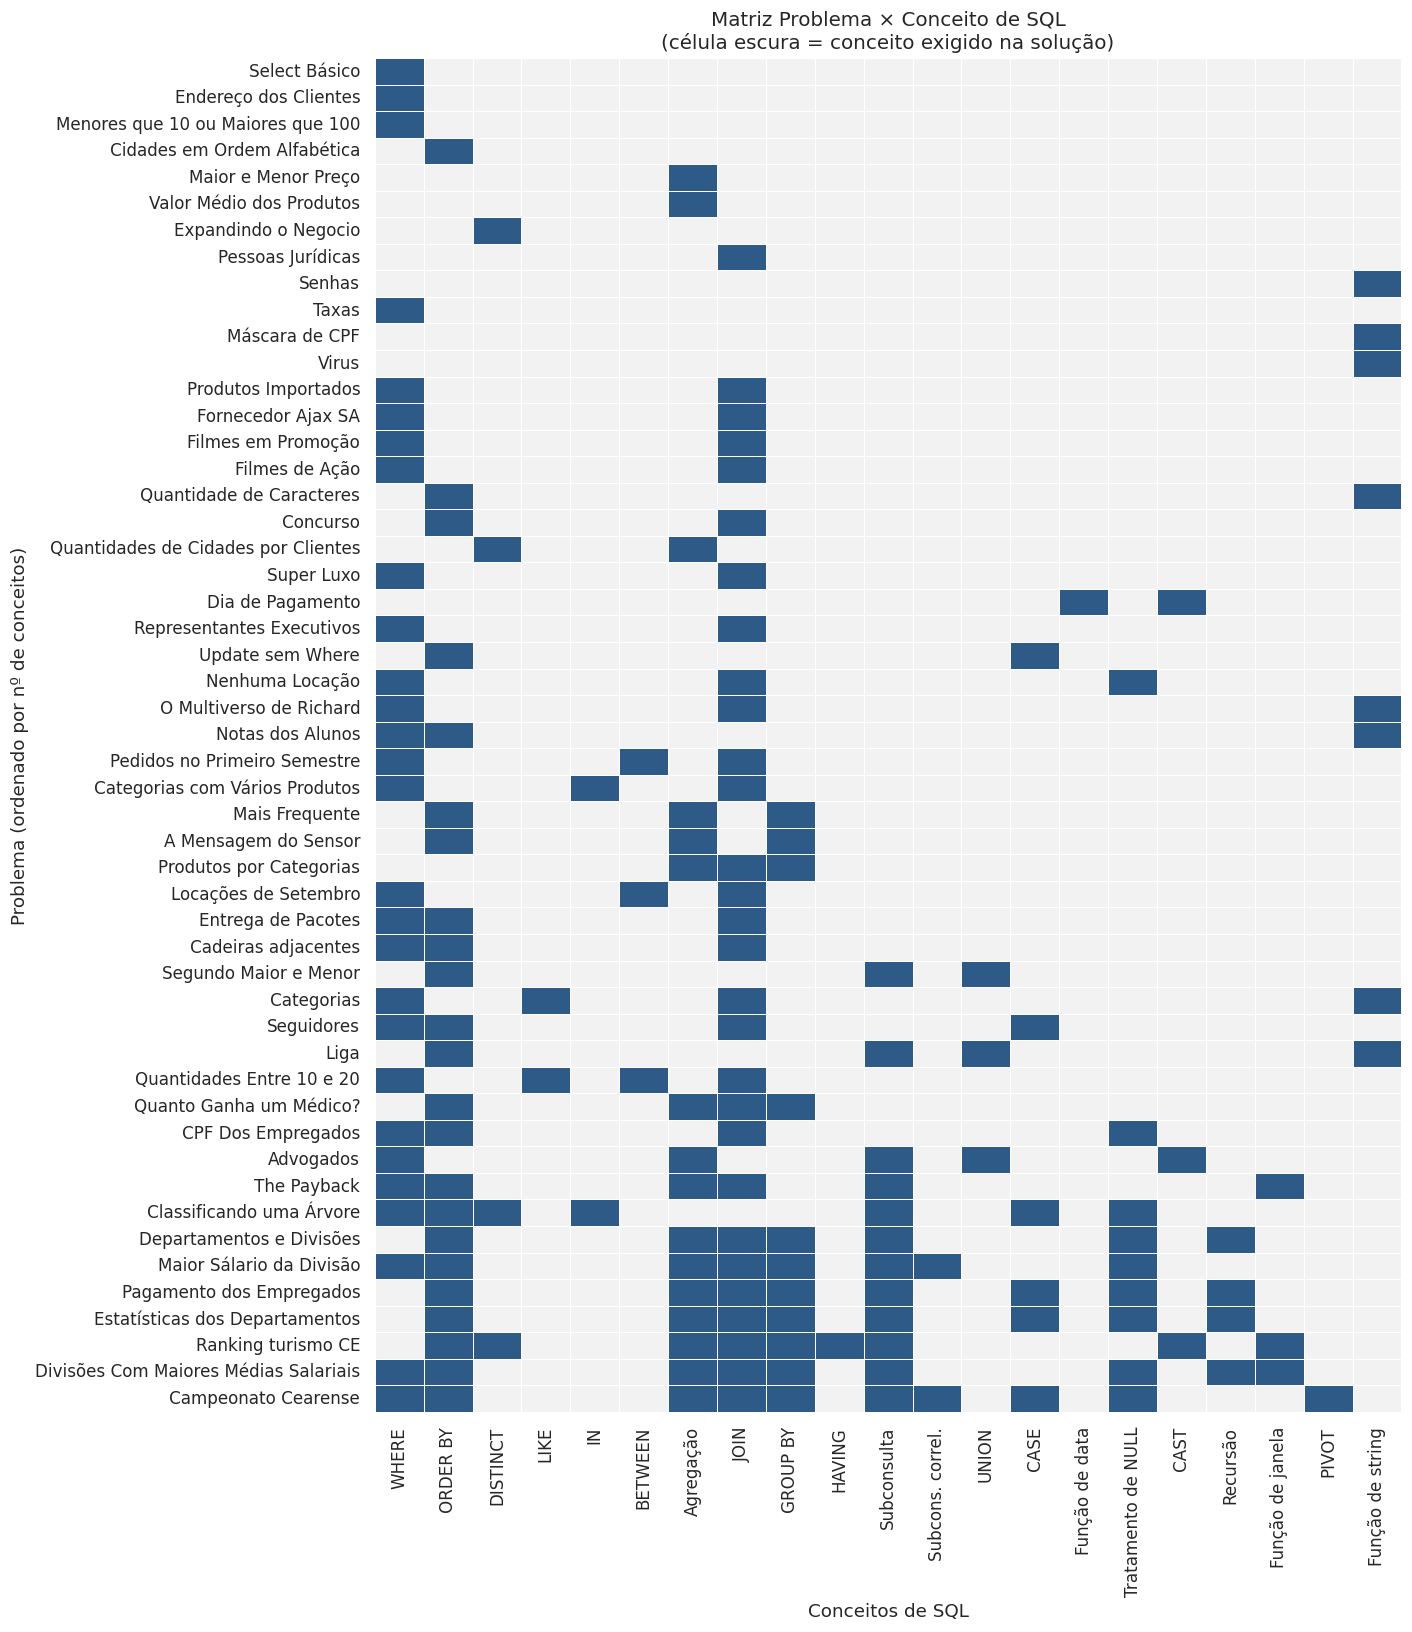

In [67]:
mat = df.sort_values("num_conceitos_total").set_index("titulo")[usa_cols]
mat.columns = rotular(mat.columns)

plt.figure(figsize=(13, 15))
sns.heatmap(mat, cmap=["#F2F2F2", "#2E5A87"], cbar=False, linewidths=0.4, linecolor="white")
plt.title("Matriz Problema × Conceito de SQL\n(célula escura = conceito exigido na solução)", fontsize=13)
plt.xlabel("Conceitos de SQL"); plt.ylabel("Problema (ordenado por nº de conceitos)")
plt.tight_layout(); plt.show()

### 4.2 Densidade conceitual — problemas-síntese (Top 15)



,problema_id,titulo,nivel,num_conceitos_total,conceito_primario,conceitos_lista
0,2988,Campeonato Cearense,4,10,Subconsulta correlacionada,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
1,2992,Divisões Com Maiores Médias Salariais,7,9,Recursão,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
2,3492,Ranking turismo CE,1,9,Função de janela,"ORDER BY, DISTINCT, Agregação, JOIN, GROUP BY,..."
3,2991,Estatísticas dos Departamentos,9,8,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
4,2997,Pagamento dos Empregados,9,8,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
5,2999,Maior Sálario da Divisão,5,8,Subconsulta correlacionada,"WHERE, ORDER BY, Agregação, JOIN, GROUP BY, Su..."
6,2989,Departamentos e Divisões,7,7,Recursão,"ORDER BY, Agregação, JOIN, GROUP BY, Subconsul..."
7,3481,Classificando uma Árvore,2,7,Subconsulta,"WHERE, ORDER BY, DISTINCT, IN, Subconsulta, CA..."
8,2998,The Payback,6,6,Função de janela,"WHERE, ORDER BY, Agregação, JOIN, Subconsulta,..."
9,2737,Advogados,6,5,Subconsulta,"WHERE, Agregação, Subconsulta, UNION, CAST"


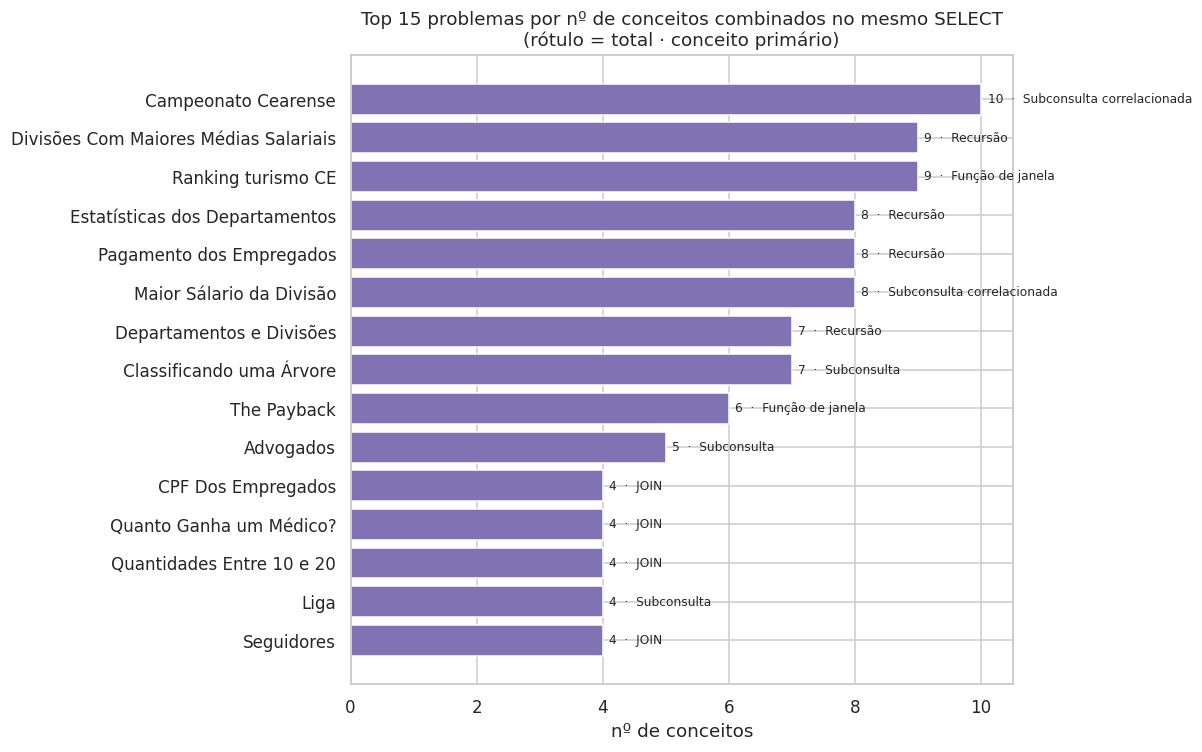

In [68]:
top = df.nlargest(15, "num_conceitos_total")[
    ["problema_id", "titulo", "nivel", "num_conceitos_total", "conceito_primario", "conceitos_lista"]
].reset_index(drop=True)
display(top)

plt.figure(figsize=(11, 7))
d = df.sort_values("num_conceitos_total", ascending=True).tail(15)
plt.barh(d["titulo"], d["num_conceitos_total"], color="#8172B3")
for i, (v, cp) in enumerate(zip(d["num_conceitos_total"], d["conceito_primario"])):
    plt.text(v + 0.1, i, f"{int(v)}  ·  {cp}", va="center", fontsize=8)
plt.title("Top 15 problemas por nº de conceitos combinados no mesmo SELECT\n(rótulo = total · conceito primário)")
plt.xlabel("nº de conceitos"); plt.tight_layout(); plt.show()

### 4.3 Mapa de escolha: conceito primário × faixa de complexidade



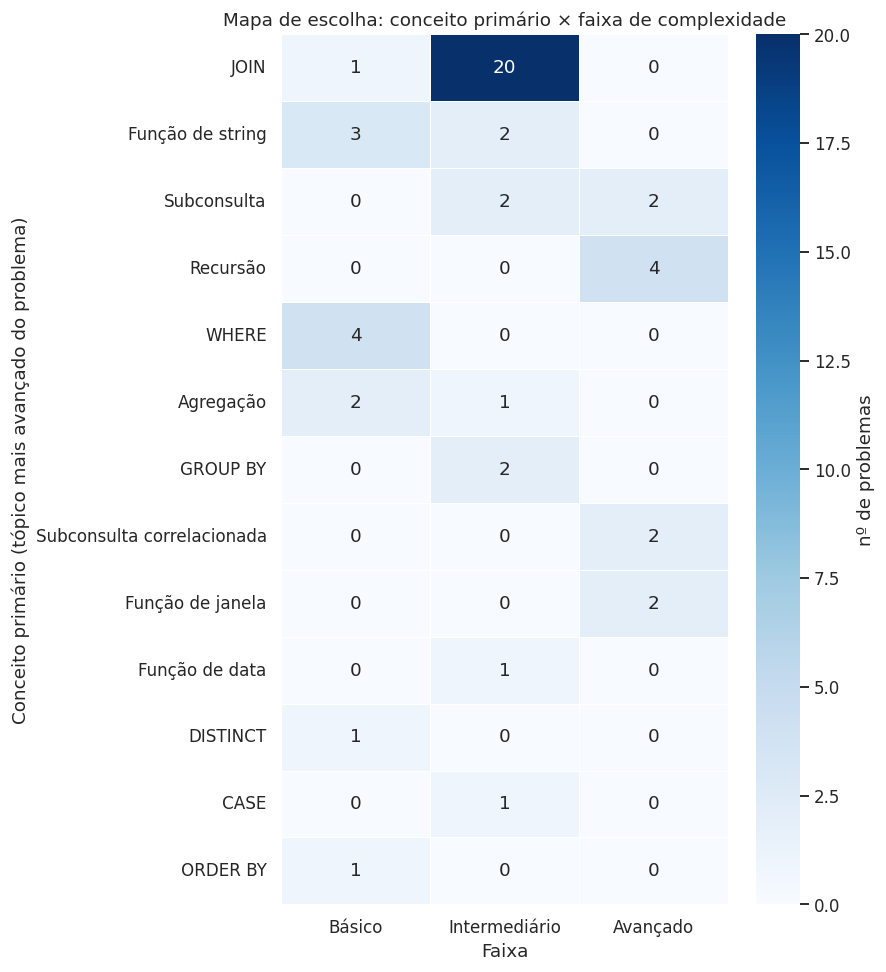

faixa_conceitual,Básico,Intermediário,Avançado
conceito_primario,,,
JOIN,1,20,0
Função de string,3,2,0
Subconsulta,0,2,2
Recursão,0,0,4
WHERE,4,0,0
Agregação,2,1,0
GROUP BY,0,2,0
Subconsulta correlacionada,0,0,2
Função de janela,0,0,2


In [69]:
pivot = pd.crosstab(df["conceito_primario"], df["faixa_conceitual"])
pivot = pivot.reindex(columns=["Básico", "Intermediário", "Avançado"], fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 9))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "nº de problemas"})
plt.title("Mapa de escolha: conceito primário × faixa de complexidade")
plt.ylabel("Conceito primário (tópico mais avançado do problema)"); plt.xlabel("Faixa")
plt.tight_layout(); plt.show()
pivot

## 5. Aprendizado de Máquina I — Clusterização (K-Means)



In [70]:
feat_conceito  = usa_cols
feat_estrutura = ["num_fks_entrada", "entrada_tem_ddl_avancado", "nivel"]
feat_enunciado = ["enunciado_num_sentencas", "enunciado_riqueza_lexica"]
features = feat_conceito + feat_estrutura + feat_enunciado

X = df[features].fillna(0).astype(float)
X_scaled = StandardScaler().fit_transform(X)   # padronização: K-Means é sensível à escala
print("Matriz de features:", X_scaled.shape)

Matriz de features: (51, 26)


### 5.1 Análise de hiperparâmetros — escolha de *k*




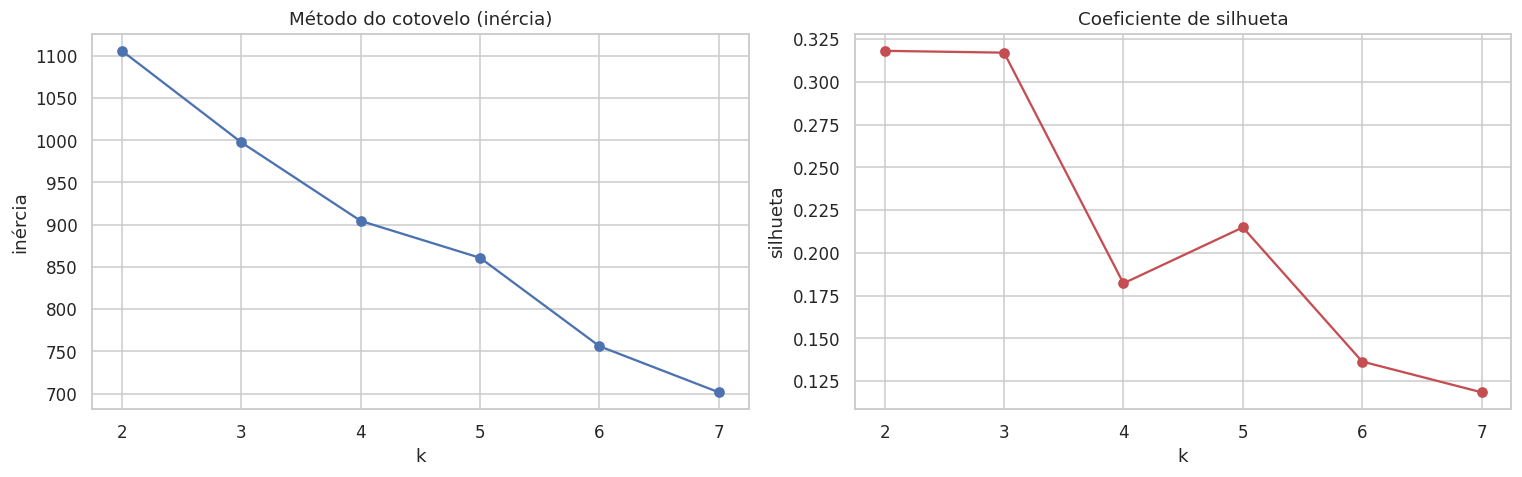

k=2: silhueta=0.318
k=3: silhueta=0.317
k=4: silhueta=0.182
k=5: silhueta=0.215
k=6: silhueta=0.136
k=7: silhueta=0.118

Melhor k pela silhueta: 2


In [71]:
ks = range(2, 8)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(ks), inercias, "o-", color="#4C72B0"); ax[0].set_title("Método do cotovelo (inércia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inércia")
ax[1].plot(list(ks), silhuetas, "o-", color="#C44E52"); ax[1].set_title("Coeficiente de silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhueta")
plt.tight_layout(); plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta={s:.3f}")
melhor_k = list(ks)[int(np.argmax(silhuetas))]
print(f"\nMelhor k pela silhueta: {melhor_k}")

### 5.2 Perfil dos clusters




In [72]:
k = 3
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)

tmp = df.copy(); tmp["_lab"] = km.labels_
ordem = tmp.groupby("_lab")["num_conceitos_total"].mean().sort_values().index
remap = {c: i for i, c in enumerate(ordem)}
df["cluster_final"] = [remap[l] for l in km.labels_]

perfil = df.groupby("cluster_final").agg(
    n=("problema_id", "count"),
    nivel_medio=("nivel", "mean"),
    conceitos_medio=("num_conceitos_total", "mean"),
    fks_medio=("num_fks_entrada", "mean"),
    resolvidos_medio=("num_resolvidos", "mean"),
    riqueza_media=("enunciado_riqueza_lexica", "mean"),
).round(2)
perfil

,n,nivel_medio,conceitos_medio,fks_medio,resolvidos_medio,riqueza_media
cluster_final,,,,,,
0,44,3.27,2.55,1.00,12014.70,0.76
1,6,6.83,8.33,0.67,1478.33,0.74
2,1,1.00,9.00,2.00,50.00,0.66


### 5.3 Visualização dos clusters via PCA (2D)



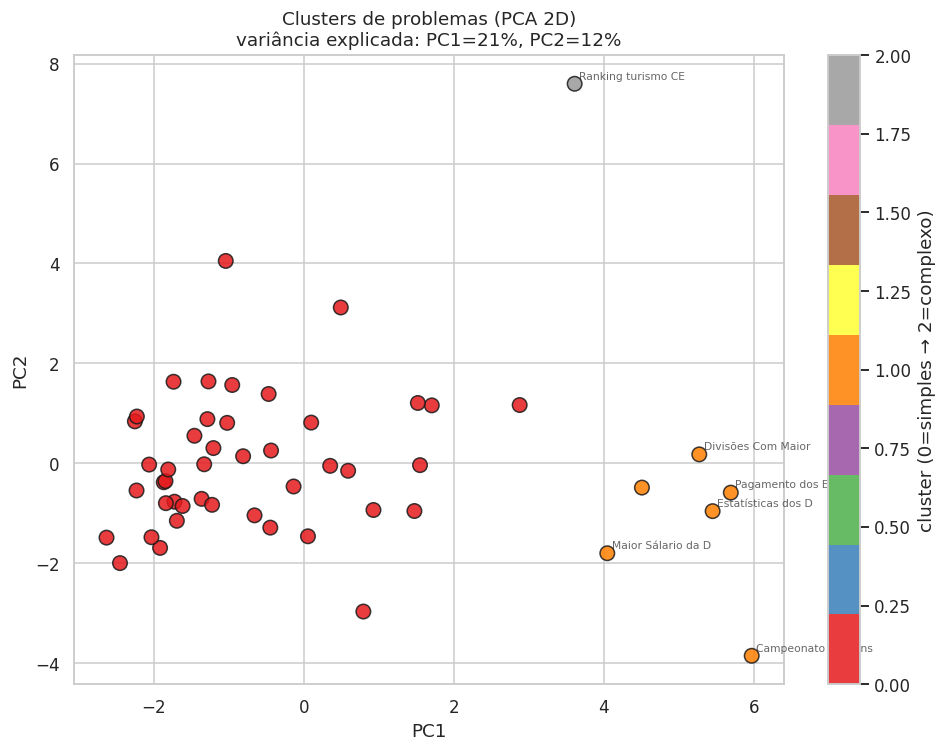

In [73]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster_final"],
                 cmap="Set1", s=90, edgecolor="k", alpha=0.85)
for i, r in df.iterrows():
    if r["num_conceitos_total"] >= 8:
        plt.annotate(str(r["titulo"])[:18], (coords[i, 0], coords[i, 1]),
                     fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.title(f"Clusters de problemas (PCA 2D)\n"
          f"variância explicada: PC1={var[0]:.0%}, PC2={var[1]:.0%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="cluster (0=simples → 2=complexo)")
plt.tight_layout(); plt.show()

## 6. Regras de Associação (Apriori)



### 6.1 Itemsets frequentes e geração das regras



In [74]:
cesta = df[usa_cols].astype(bool)
cesta.columns = rotular(usa_cols)

freq = apriori(cesta, min_support=0.12, use_colnames=True, max_len=3)
print(f"Itemsets frequentes (sup≥0.12, até 3 itens): {len(freq)}")

regras = association_rules(freq, metric="confidence", min_threshold=0.6)
regras = regras[regras["lift"] > 1.2].copy()
regras["n_ant"] = regras["antecedents"].apply(len)
regras["n_con"] = regras["consequents"].apply(len)
regras = regras[(regras["n_ant"] <= 2) & (regras["n_con"] == 1)]
regras = regras.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

def _fmt(itemset): return " + ".join(sorted(itemset))
regras["Antecedente"] = regras["antecedents"].apply(_fmt)
regras["Consequente"] = regras["consequents"].apply(_fmt)

tabela = regras[["Antecedente", "Consequente", "support", "confidence", "lift"]].round(3)
tabela.columns = ["Antecedente", "Consequente", "Suporte", "Confiança", "Lift"]
print(f"Regras robustas e interpretáveis: {len(tabela)}")
display(tabela.head(15))

Itemsets frequentes (sup≥0.12, até 3 itens): 36
Regras robustas e interpretáveis: 47


,Antecedente,Consequente,Suporte,Confiança,Lift
0,Agregação + ORDER BY,GROUP BY,0.196,0.909,4.215
1,Agregação + JOIN,GROUP BY,0.176,0.900,4.173
2,JOIN + Subconsulta,GROUP BY,0.137,0.875,4.057
3,ORDER BY + Tratamento de NULL,Subconsulta,0.137,0.875,3.719
4,Agregação + Subconsulta,GROUP BY,0.137,0.778,3.606
5,ORDER BY + Subconsulta,Tratamento de NULL,0.137,0.636,3.606
6,Agregação + JOIN,Subconsulta,0.157,0.800,3.400
7,Tratamento de NULL,Subconsulta,0.137,0.778,3.306
8,GROUP BY + JOIN,Subconsulta,0.137,0.778,3.306
9,GROUP BY,Agregação,0.216,1.000,3.188


### 6.2 Visualização — suporte × confiança (cor = lift)

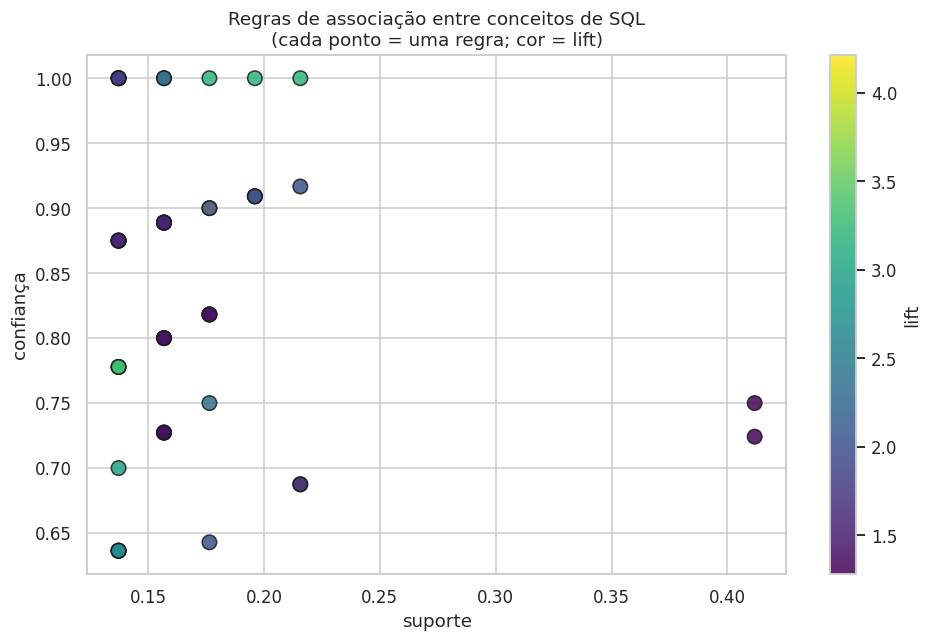

In [75]:
plt.figure(figsize=(9, 6))
sc = plt.scatter(regras["support"], regras["confidence"],
                 c=regras["lift"], cmap="viridis", s=90, edgecolor="k", alpha=0.85)
plt.colorbar(sc, label="lift")
plt.xlabel("suporte"); plt.ylabel("confiança")
plt.title("Regras de associação entre conceitos de SQL\n(cada ponto = uma regra; cor = lift)")
plt.tight_layout(); plt.show()

### 6.3 Top 12 regras por lift

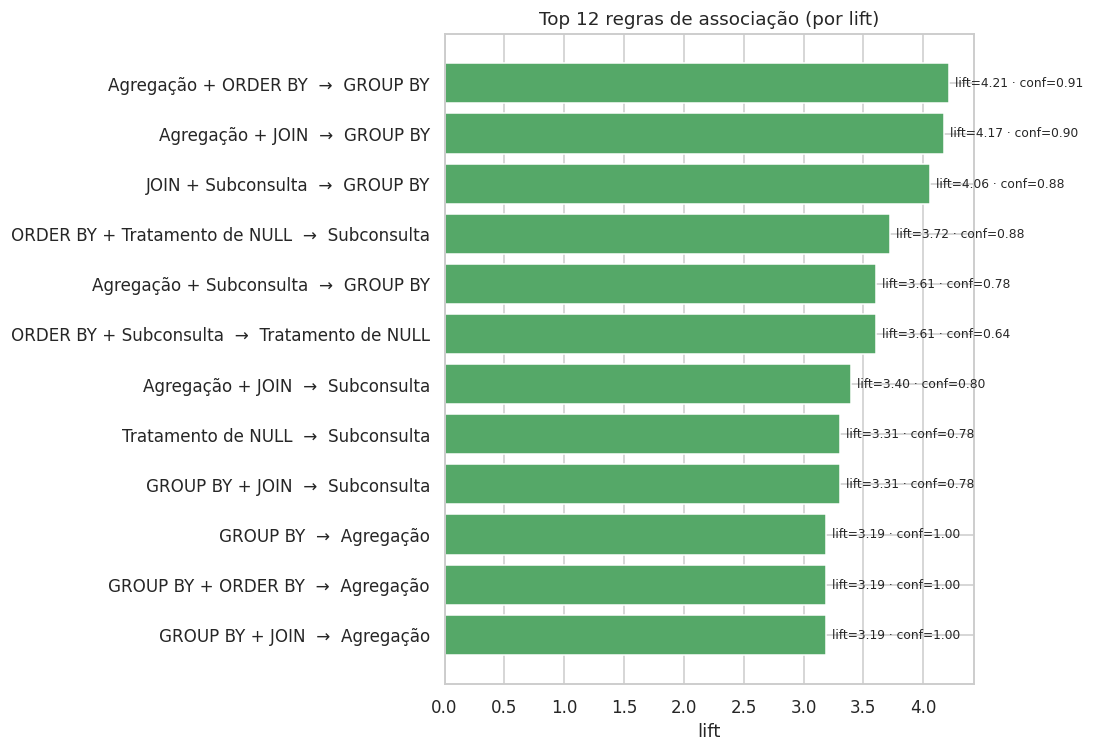

In [76]:
top_r = regras.head(12).iloc[::-1]
rot = top_r["Antecedente"] + "  →  " + top_r["Consequente"]
plt.figure(figsize=(10, 7))
plt.barh(rot, top_r["lift"], color="#55A868", edgecolor="white")
for i, (l, c) in enumerate(zip(top_r["lift"], top_r["confidence"])):
    plt.text(l + 0.05, i, f"lift={l:.2f} · conf={c:.2f}", va="center", fontsize=8)
plt.xlabel("lift"); plt.title("Top 12 regras de associação (por lift)")
plt.tight_layout(); plt.show()

## 7. Respostas às questões de pesquisa


### QP2 — Coerência entre nível declarado e complexidade técnica real


Correlação nível × complexidade técnica:
  Pearson  r = 0.512 (p=0.0001)
  Spearman ρ = 0.465 (p=0.0006)


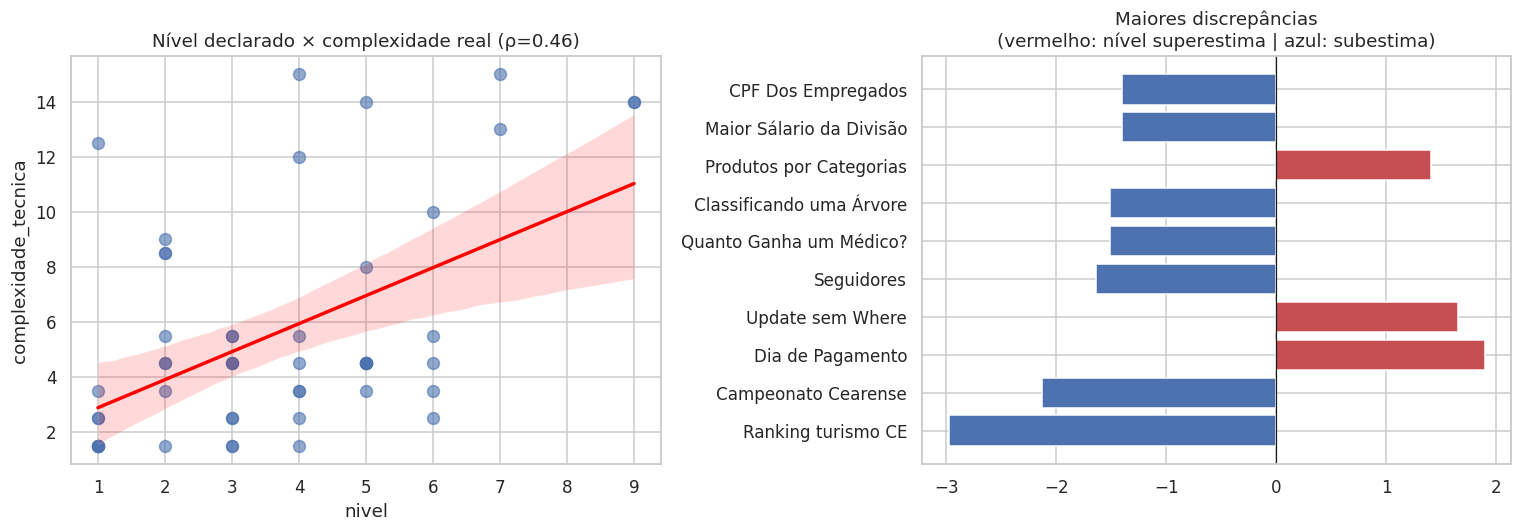

In [77]:
rho, p_s = spearmanr(df["nivel"], df["complexidade_tecnica"])
r, p_p   = pearsonr(df["nivel"], df["complexidade_tecnica"])
print("Correlação nível × complexidade técnica:")
print(f"  Pearson  r = {r:.3f} (p={p_p:.4f})")
print(f"  Spearman ρ = {rho:.3f} (p={p_s:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df, x="nivel", y="complexidade_tecnica", ax=ax[0],
            scatter_kws={"s": 60, "alpha": .6}, line_kws={"color": "red"})
ax[0].set_title(f"Nível declarado × complexidade real (ρ={rho:.2f})")

disc = df.reindex(df["discrepancia_nivel_complexidade"].abs().sort_values(ascending=False).index)
top_disc = disc.head(10)
ax[1].barh(top_disc["titulo"], top_disc["discrepancia_nivel_complexidade"],
           color=["#C44E52" if v > 0 else "#4C72B0" for v in top_disc["discrepancia_nivel_complexidade"]])
ax[1].axvline(0, color="k", lw=.8)
ax[1].set_title("Maiores discrepâncias\n(vermelho: nível superestima | azul: subestima)")
plt.tight_layout(); plt.show()

### QP3 — Contexto narrativo × conceitos exigidos




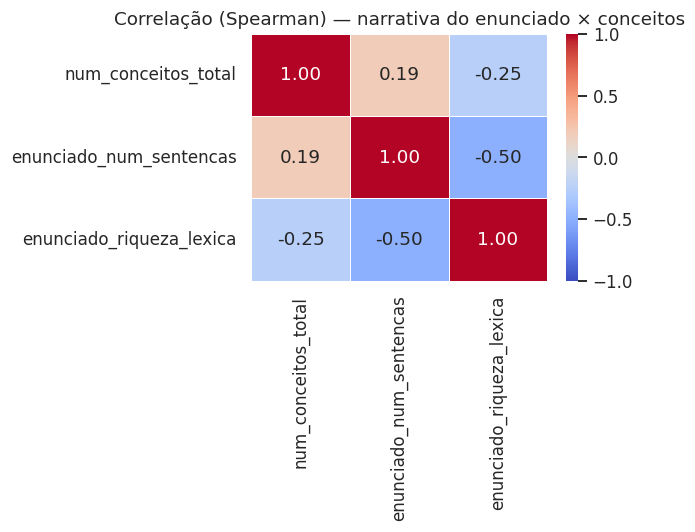

In [78]:
cols_qp3 = ["num_conceitos_total", "enunciado_num_sentencas", "enunciado_riqueza_lexica"]
corr = df[cols_qp3].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=.5)
plt.title("Correlação (Spearman) — narrativa do enunciado × conceitos")
plt.tight_layout(); plt.show()